In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set styles for plots
sns.set(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (9, 5)

In [2]:
# Load the dataset
df = pd.read_csv('lifestyle_sustainability_data.csv')

# Display first few rows and structure
display(df.head())
print("\nColumn Names:\n", df.columns.tolist())
print("\nDataset shape:", df.shape)

,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
0,1,35,Urban,Mostly Plant-Based,Often,Bike,Renewable,Apartment,800,Rarely,True,5,High,100,1500,Female,Rarely,Composting,High,5
1,2,28,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1500,Sometimes,True,4,Moderate,250,3000,Male,Sometimes,Recycling,Moderate,4
2,3,65,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2500,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,1
3,4,42,Urban,Mostly Plant-Based,Often,Walk,Renewable,Apartment,950,Sometimes,True,4,Moderate,150,2000,Female,Rarely,Recycling,High,5
4,5,31,Suburban,Balanced,Sometimes,Public Transit,Mixed,House,1800,Often,True,3,Low,300,3500,Non-Binary,Sometimes,Combination,Moderate,3



Column Names:
 ['ParticipantID', 'Age', 'Location', 'DietType', 'LocalFoodFrequency', 'TransportationMode', 'EnergySource', 'HomeType', 'HomeSize', 'ClothingFrequency', 'SustainableBrands', 'EnvironmentalAwareness', 'CommunityInvolvement', 'MonthlyElectricityConsumption', 'MonthlyWaterConsumption', 'Gender', 'UsingPlasticProducts', 'DisposalMethods', 'PhysicalActivities', 'Rating']

Dataset shape: (499, 20)


In [3]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert Rating to numeric (in case it's read as string)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Confirm cleanup
print(f"\nCleaned dataset shape: {df.shape}")

Missing values per column:
 ParticipantID                      0
Age                                0
Location                           0
DietType                           0
LocalFoodFrequency                 0
TransportationMode                 0
EnergySource                       0
HomeType                           0
HomeSize                           0
ClothingFrequency                  0
SustainableBrands                  0
EnvironmentalAwareness             0
CommunityInvolvement             118
MonthlyElectricityConsumption      0
MonthlyWaterConsumption            0
Gender                             0
UsingPlasticProducts               0
DisposalMethods                    0
PhysicalActivities               108
Rating                             0
dtype: int64

Cleaned dataset shape: (499, 20)


C:\Users\DELL\AppData\Local\Temp\ipykernel_15440\3170723587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette="crest")


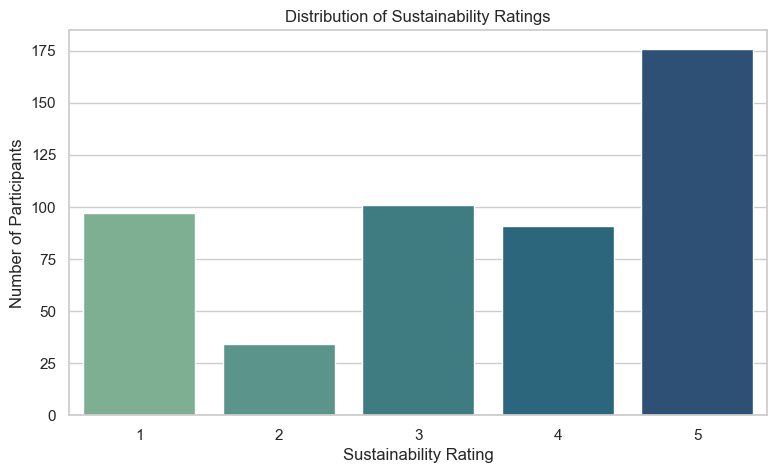

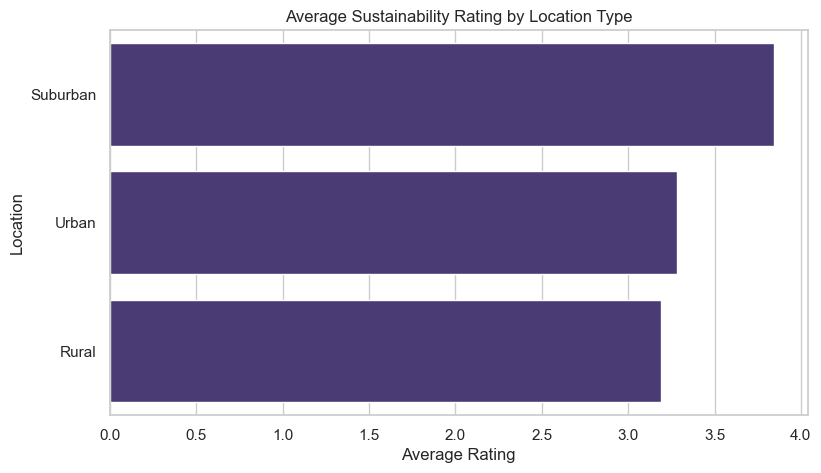

In [4]:
# Plot distribution of sustainability ratings
sns.countplot(x='Rating', data=df, palette="crest")
plt.title("Distribution of Sustainability Ratings")
plt.xlabel("Sustainability Rating")
plt.ylabel("Number of Participants")
plt.show()

# Average rating by location
avg_rating_location = df.groupby('Location')['Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating_location.values, y=avg_rating_location.index)
plt.title("Average Sustainability Rating by Location Type")
plt.xlabel("Average Rating")
plt.show()

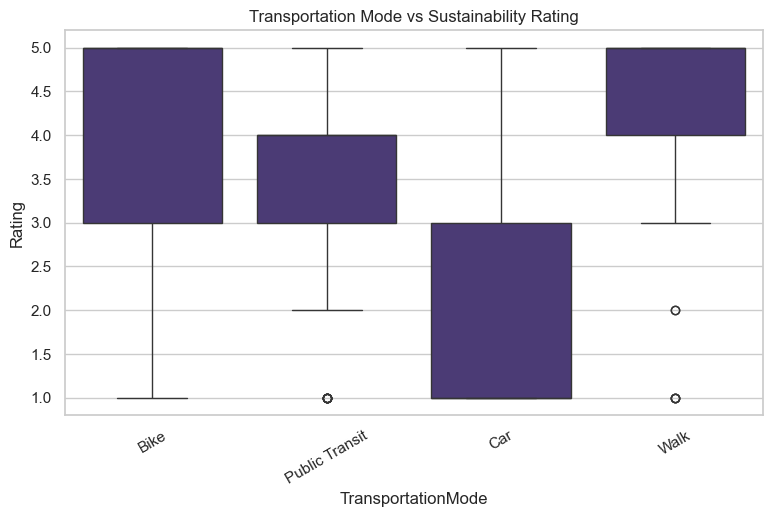

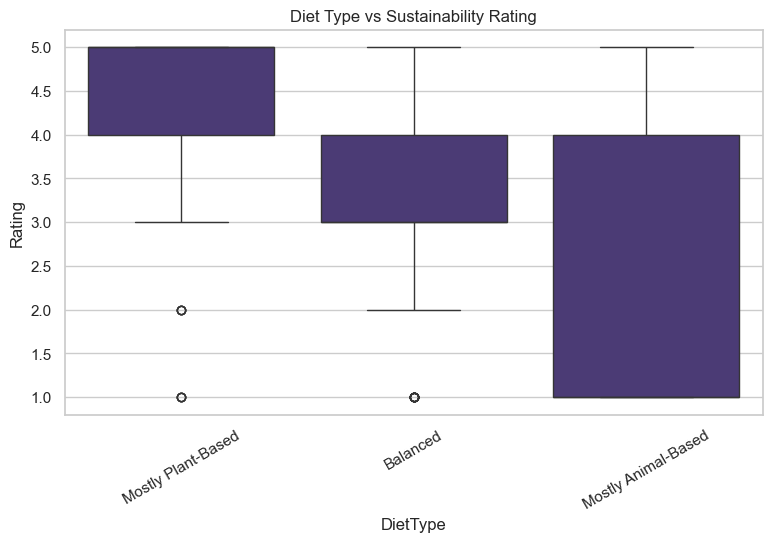

In [5]:
# Transportation Mode vs Rating
sns.boxplot(x='TransportationMode', y='Rating', data=df)
plt.title("Transportation Mode vs Sustainability Rating")
plt.xticks(rotation=30)
plt.show()

# Diet Type vs Rating
sns.boxplot(x='DietType', y='Rating', data=df)
plt.title("Diet Type vs Sustainability Rating")
plt.xticks(rotation=30)
plt.show()

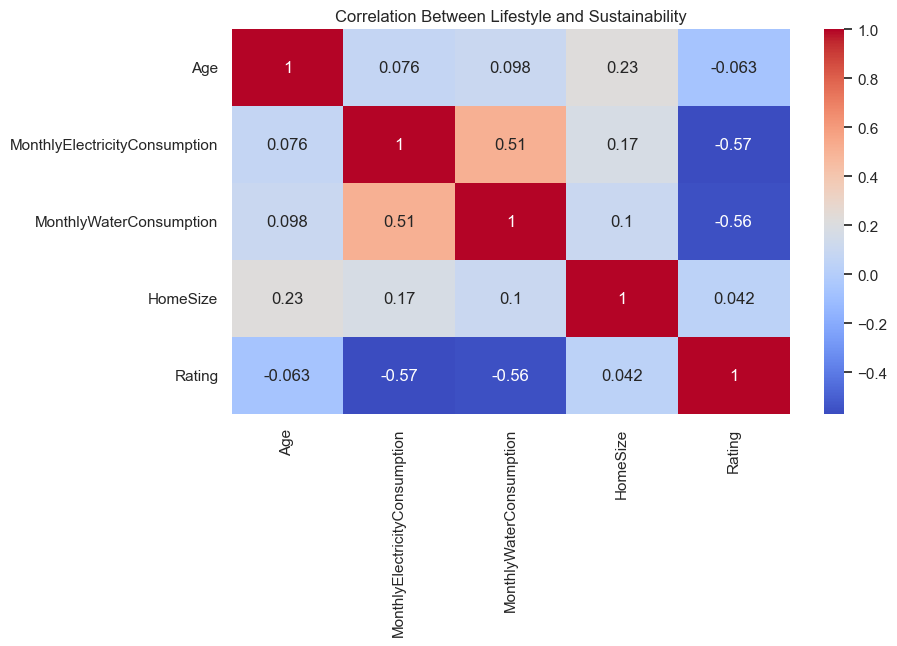

In [6]:
# Correlation heatmap
corr = df[['Age', 'MonthlyElectricityConsumption', 'MonthlyWaterConsumption', 'HomeSize', 'Rating']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Lifestyle and Sustainability")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_15440\3117197946.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='EnergySource', y='Rating', data=df, estimator=np.mean, ci=None)


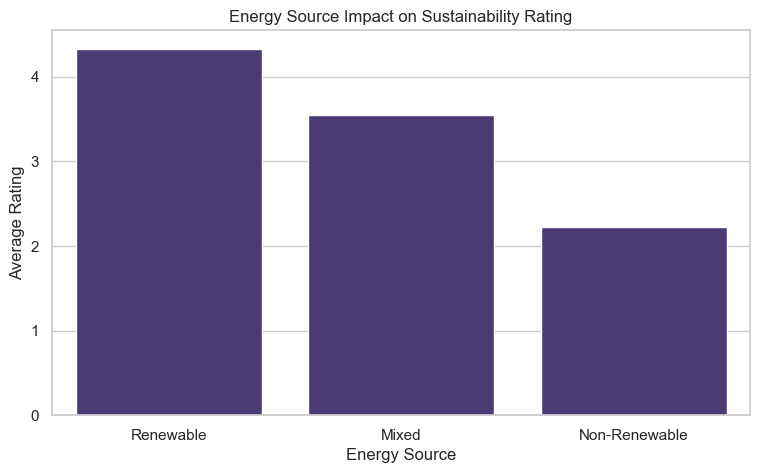

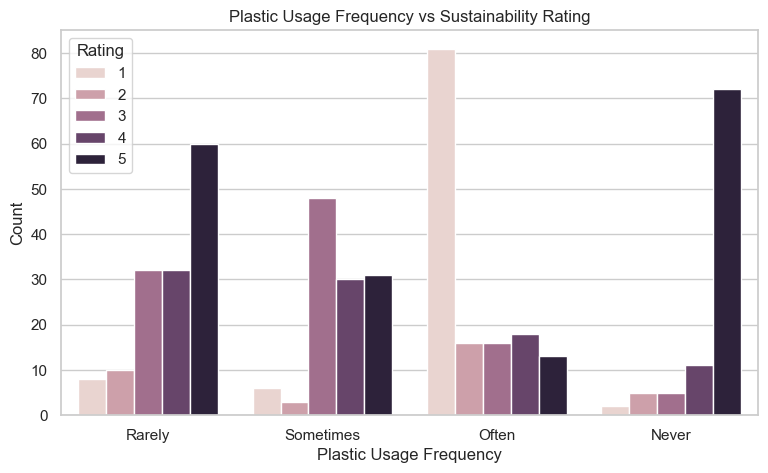

In [7]:
# Average rating by energy source
sns.barplot(x='EnergySource', y='Rating', data=df, estimator=np.mean, ci=None)
plt.title("Energy Source Impact on Sustainability Rating")
plt.xlabel("Energy Source")
plt.ylabel("Average Rating")
plt.show()

# Plastic usage vs Rating
sns.countplot(x='UsingPlasticProducts', hue='Rating', data=df)
plt.title("Plastic Usage Frequency vs Sustainability Rating")
plt.xlabel("Plastic Usage Frequency")
plt.ylabel("Count")
plt.show()

In [8]:
# Identify top 20% and bottom 20% participants
top = df[df['Rating'] >= df['Rating'].quantile(0.8)]
low = df[df['Rating'] <= df['Rating'].quantile(0.2)]

print("High Sustainability Lifestyle Examples:")
display(top.head())

print("Low Sustainability Lifestyle Examples:")
display(low.head())

High Sustainability Lifestyle Examples:


,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
0,1,35,Urban,Mostly Plant-Based,Often,Bike,Renewable,Apartment,800,Rarely,True,5,High,100,1500,Female,Rarely,Composting,High,5
3,4,42,Urban,Mostly Plant-Based,Often,Walk,Renewable,Apartment,950,Sometimes,True,4,Moderate,150,2000,Female,Rarely,Recycling,High,5
6,7,25,Urban,Mostly Plant-Based,Always,Bike,Renewable,Other,600,Rarely,True,5,High,80,1200,Female,Never,Composting,High,5
10,11,48,Suburban,Mostly Plant-Based,Often,Bike,Renewable,House,1400,Sometimes,True,5,High,120,1800,Male,Rarely,Composting,High,5
13,14,27,Urban,Mostly Plant-Based,Always,Walk,Renewable,House,1300,Rarely,True,4,Moderate,160,2200,Female,Never,Composting,High,5


Low Sustainability Lifestyle Examples:


,ParticipantID,Age,Location,DietType,LocalFoodFrequency,TransportationMode,EnergySource,HomeType,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,Gender,UsingPlasticProducts,DisposalMethods,PhysicalActivities,Rating
2,3,65,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2500,Often,False,2,Low,400,4500,Male,Often,Landfill,Low,1
5,6,58,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,House,2200,Always,False,1,NaN,450,5000,Male,Often,Landfill,NaN,1
9,10,29,Urban,Mostly Animal-Based,Rarely,Car,Non-Renewable,Apartment,1100,Always,False,2,NaN,380,4200,Non-Binary,Often,Landfill,NaN,1
12,13,61,Rural,Mostly Animal-Based,Rarely,Car,Non-Renewable,Other,750,Always,False,1,NaN,420,4800,Male,Often,Landfill,NaN,1
16,17,32,Urban,Mostly Animal-Based,Rarely,Car,Non-Renewable,Other,650,Always,False,2,NaN,400,4600,Male,Often,Landfill,NaN,1


In [9]:
def lifestyle_recommendations(row):
    recs = []

    if row['TransportationMode'] == 'Car':
        recs.append("Consider using public transit, biking, or walking more often.")
    if row['EnergySource'] in ['Non-Renewable', 'Mixed']:
        recs.append("Switch to renewable energy sources like solar or wind.")
    if row['UsingPlasticProducts'] in ['Often', 'Sometimes']:
        recs.append("Reduce single-use plastic and switch to reusable materials.")
    if row['DisposalMethods'] in ['Landfill', 'Combination']:
        recs.append("Adopt composting or proper recycling methods.")
    if row['DietType'] == 'Mostly Animal-Based':
        recs.append("Include more plant-based meals in your diet for lower carbon impact.")
    if row['MonthlyWaterConsumption'] > df['MonthlyWaterConsumption'].median():
        recs.append("Reduce water usage through efficient fixtures and habits.")
    if row['MonthlyElectricityConsumption'] > df['MonthlyElectricityConsumption'].median():
        recs.append("Use energy-efficient appliances and unplug unused devices.")

    return recs if recs else ["Keep up your great eco-friendly habits! 🌍"]

# Apply the recommender to low-rating participants
low['Recommendations'] = low.apply(lifestyle_recommendations, axis=1)

display(low[['ParticipantID', 'Rating', 'TransportationMode', 'EnergySource', 'DietType', 'UsingPlasticProducts', 'Recommendations']].head())

C:\Users\DELL\AppData\Local\Temp\ipykernel_15440\318391898.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low['Recommendations'] = low.apply(lifestyle_recommendations, axis=1)


,ParticipantID,Rating,TransportationMode,EnergySource,DietType,UsingPlasticProducts,Recommendations
2,3,1,Car,Non-Renewable,Mostly Animal-Based,Often,"[Consider using public transit, biking, or wal..."
5,6,1,Car,Non-Renewable,Mostly Animal-Based,Often,"[Consider using public transit, biking, or wal..."
9,10,1,Car,Non-Renewable,Mostly Animal-Based,Often,"[Consider using public transit, biking, or wal..."
12,13,1,Car,Non-Renewable,Mostly Animal-Based,Often,"[Consider using public transit, biking, or wal..."
16,17,1,Car,Non-Renewable,Mostly Animal-Based,Often,"[Consider using public transit, biking, or wal..."


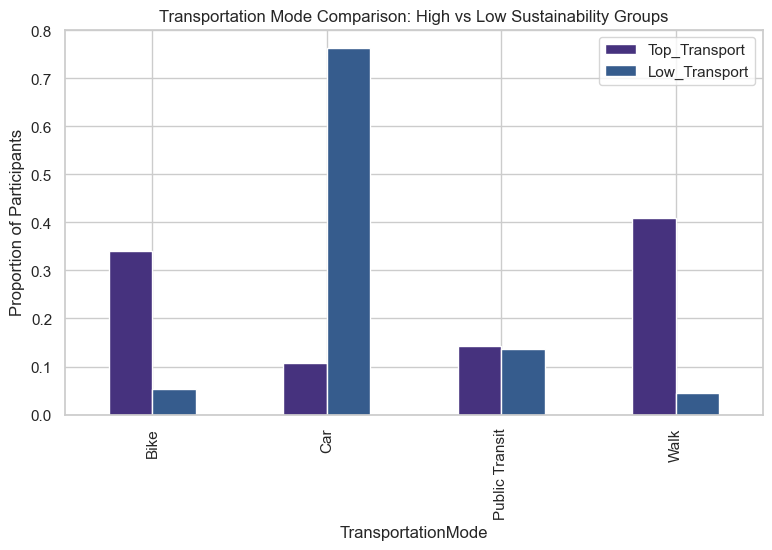

In [10]:
compare = pd.DataFrame({
    'Top_Transport': top['TransportationMode'].value_counts(normalize=True),
    'Low_Transport': low['TransportationMode'].value_counts(normalize=True)
}).fillna(0)

compare.plot(kind='bar')
plt.title("Transportation Mode Comparison: High vs Low Sustainability Groups")
plt.ylabel("Proportion of Participants")
plt.show()

In [11]:
# Save the low-rating users and their recommendations
low[['ParticipantID', 'Rating', 'Recommendations']].to_csv('sustainability_recommendations.csv', index=False)
print("Recommendations saved to 'sustainability_recommendations.csv'")

Recommendations saved to 'sustainability_recommendations.csv'
